In [4]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv
from src.utils import compute_distance_tables_threaded, compute_distance_tables_vectorized, adc_distances_batch_numba\
                    , compute_all_distances_batch, adc_distances_all_optimized, lsq_alpha_from_codes \
                    , lsq_dot_tables_vectorized, lsq_distances_batch_numba
  



In [5]:
# Loading the GIST dataset
db = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_base.fvecs'))
qr = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_query.fvecs'))


Reading File - /data/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)


In [ ]:
import os, numpy as np

def fvecs_info(path):
    with open(path, "rb") as f:
        d = np.fromfile(f, dtype=np.int32, count=1)[0]
    rec_bytes = (d + 1) * 4
    n = os.path.getsize(path) // rec_bytes
    return int(n), int(d), rec_bytes

def fvecs_read_chunk(path, start, count, d):
    rec = d + 1
    a = np.fromfile(path, dtype=np.int32, count=count*rec, offset=start*rec*4)
    a = a.reshape(-1, rec)
    return a[:, 1:].view(np.float32)  # returns a copy

def compute_centroid_fvecs(path, chunk=200_000):
    n, d, _ = fvecs_info(path)
    s = np.zeros(d, dtype=np.float64)   # accumulate in float64 for accuracy
    done = 0
    for i0 in range(0, n, chunk):
        m = min(chunk, n - i0)
        X = fvecs_read_chunk(path, i0, m, d)  # [m, d] float32
        s += X.sum(axis=0, dtype=np.float64)
        done += m
        # (optional) print progress
        # print(f"{done}/{n}")
    c = (s / done).astype(np.float32)
    return c




learn_path = "/data/cpanourg/2-hdvc/data/gist/gist_learn.fvecs"  # <- your path
centroid = compute_centroid_fvecs(learn_path)
np.save("/data/cpanourg/2-hdvc/data/gist/centroid.npy", centroid)
print("Saved centroid.npy with shape", centroid.shape)


500000
Saved centroid.npy with shape (960,)


In [29]:
import os, math, numpy as np
from ctypes import CDLL, c_int, c_int64, c_float, c_uint8, POINTER

# ---- paths
FAISS_LIB = os.path.expanduser("~/projects/2-hdvc/lib/faiss/build/faiss")
SHIM_SO   = os.path.expanduser("~/projects/2-hdvc/lib/faiss_lib_mine/build/librbqshim.so")
os.environ["LD_LIBRARY_PATH"] = FAISS_LIB + ":" + os.environ.get("LD_LIBRARY_PATH","")

# ---- load shim & declare signatures
lib = CDLL(SHIM_SO)

lib.rbq_code_size.argtypes = [c_int64]
lib.rbq_code_size.restype  = c_int64

lib.rbq_l2_distances_qbits.argtypes = [
    POINTER(c_float), c_int64,             # query*, d
    POINTER(c_uint8), c_int64,             # codes*, n
    POINTER(c_float),                      # centroid*
    c_int, c_int, c_int,                   # qb, centered, metric (0=L2, 1=IP)
    POINTER(c_float)                       # out distances*
]
lib.rbq_l2_distances_qbits.restype = c_int

# ---- helpers
def load_codes(path, d):
    code_size = int(lib.rbq_code_size(d))
    # code_size = 128  # for 8 bits
    nbytes_bits = (d + 7) // 8
    fsz = os.path.getsize(path)
    n = fsz // code_size
    codes_mm = np.memmap(path, dtype=np.uint8, mode="r", shape=(n, code_size))
    return codes_mm, code_size, n, nbytes_bits

def read_fvecs(path, start=0, count=None):
    a0 = np.fromfile(path, dtype=np.int32, count=1)
    d = int(a0[0]); rec = d+1
    # d = 8
    if count is None:
        count = (os.path.getsize(path)//4)//rec
    a = np.fromfile(path, dtype=np.int32, count=count*rec, offset=start*rec*4)
    a = a.reshape(-1, rec)
    return a[:,1:].view(np.float32).copy(), d

# ---- your files
base_codes_path = "/data/cpanourg/2-hdvc/data/gist/gist_base.fvecs.rbq.codes.u8"    # produced earlier
centroid = np.load("/data/cpanourg/2-hdvc/data/gist/centroid.npy").astype(np.float32)  # or compute earlier
queries_path = "/data/cpanourg/2-hdvc/data/gist/gist_query.fvecs"

# load queries
Q, d = read_fvecs(queries_path)  
centroid_p = centroid.ctypes.data_as(POINTER(c_float))

# load codes memmap
codes_mm, code_size, nb, nbytes_bits = load_codes(base_codes_path, d)
print("DB:", nb, "vectors; d:", d, "code_size:", code_size, "nbytes_bits:", nbytes_bits)


DB: 1000000 vectors; d: 960 code_size: 128 nbytes_bits: 120


In [30]:
N = 10_000  # <-- only score the first N DB vectors

nq, d = Q.shape
nb = codes_mm.shape[0]
nb_eff = min(N, nb)

dist_mm = np.memmap(
    "/data/cpanourg/2-hdvc/results/rabitq/rbq_dists_firstN.f32",
    dtype=np.float32, mode="w+", shape=(nq, nb_eff)
)

db_block = 400_000
qb, centered, metric = 8, 0, 0
tmp = np.empty(db_block, dtype=np.float32)

def dists_one_query_into(q, codes_block, out_view):
    m = codes_block.shape[0]
    rc = lib.rbq_l2_distances_qbits(
        q.ctypes.data_as(POINTER(c_float)), c_int64(d),
        codes_block.ctypes.data_as(POINTER(c_uint8)), c_int64(m),
        centroid.ctypes.data_as(POINTER(c_float)),
        c_int(qb), c_int(centered), c_int(metric),
        tmp.ctypes.data_as(POINTER(c_float))
    )
    if rc != 0:
        raise RuntimeError(f"rbq distances rc={rc}")
    out_view[:] = tmp[:m]

blocks = math.ceil(nb_eff / db_block)
for b in range(blocks):
    i0 = b * db_block
    i1 = min(nb_eff, i0 + db_block)
    codes_block = codes_mm[i0:i1]  # only the first N
    for qi in range(nq):
        dists_one_query_into(Q[qi], codes_block, dist_mm[qi, i0:i1])
    print(f"[block {b+1}/{blocks}] wrote cols {i0}:{i1}")
dist_mm.flush()
print("Wrote:", dist_mm.filename)


[block 1/1] wrote cols 0:10000
Wrote: /data/cpanourg/2-hdvc/results/rabitq/rbq_dists_firstN.f32


In [17]:
import os, numpy as np

path = "/data/cpanourg/2-hdvc/results/rabitq/rbq_dists_firstN.f32"

def load_distances(path, nq=None, nb=None):
    """Return a float32 memmap of shape (nq, nb)."""
    bytes_per_f32 = 4
    size_bytes = os.path.getsize(path)
    n_floats = size_bytes // bytes_per_f32
    if nq is None and nb is None:
        raise ValueError("Provide at least one of (nq, nb).")
    if nq is None:
        if n_floats % nb != 0:
            raise ValueError("File size not divisible by nb.")
        nq = n_floats // nb
    if nb is None:
        if n_floats % nq != 0:
            raise ValueError("File size not divisible by nq.")
        nb = n_floats // nq
    return np.memmap(path, dtype=np.float32, mode="r", shape=(nq, nb))

# Example: if you know nq=1000 and kept N=250_000 DB vectors:
nq, N = 1000, 10_000
D = load_distances(path, nq=nq, nb=N)

print(D.shape)            # (1000, 250000)
print(D.dtype)            # float32


(1000, 10000)
float32


In [18]:
D

memmap([[3.4356 , 2.72681, 4.35678, ..., 2.06326, 1.55818, 5.95231],
        [2.29435, 1.96036, 3.0148 , ..., 1.57113, 1.91833, 4.46574],
        [2.90061, 3.04634, 4.9622 , ..., 1.94618, 1.76351, 6.71732],
        ...,
        [3.74498, 2.33874, 3.00141, ..., 2.27632, 2.25037, 3.38164],
        [3.73682, 2.80071, 4.64958, ..., 2.08152, 1.69876, 4.49291],
        [2.92541, 3.25491, 4.45098, ..., 1.36521, 1.39837, 4.6783 ]],
       dtype=float32)

In [19]:
# Exact distances with cdist

t0 = time.time()
exact_sample = cdist(qr, db[:10000], metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0
time.time() - t0
print(f"Time to compute exact distances: {cdist_time} seconds")

Time to compute exact distances: 4.7623677253723145 seconds


In [20]:
exact_sample

array([[4.53871, 3.13959, 5.48577, ..., 2.2722 , 1.82061, 6.48726],
       [3.41511, 2.12565, 3.667  , ..., 1.67902, 2.20642, 4.994  ],
       [4.76085, 3.62529, 6.31579, ..., 2.3211 , 2.11891, 7.61686],
       ...,
       [4.19128, 2.37005, 3.77908, ..., 2.13866, 2.33361, 3.85432],
       [4.64732, 3.01347, 5.62077, ..., 2.37883, 1.84327, 5.27314],
       [5.12613, 3.89695, 6.2971 , ..., 1.81359, 1.89352, 6.44681]],
      dtype=float32)

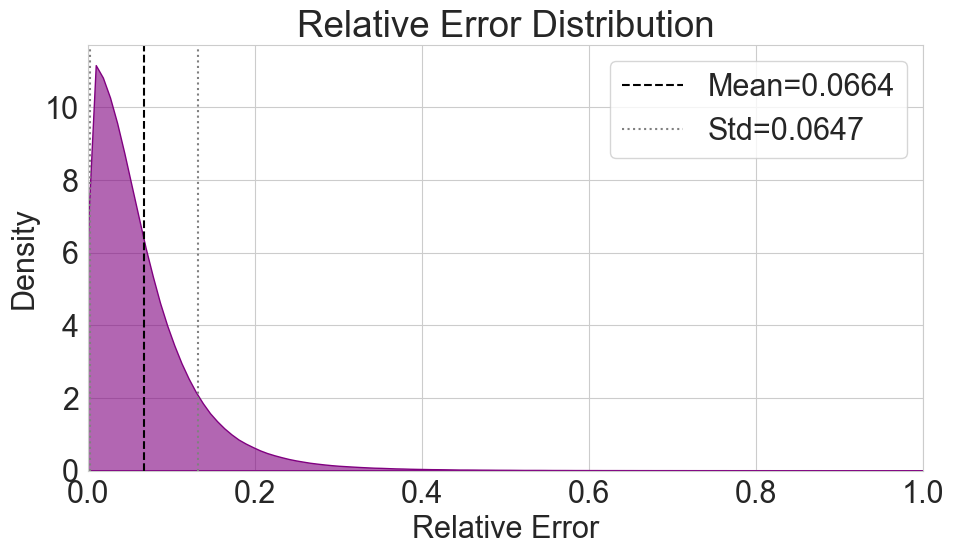

In [21]:

plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")
# Relative errors
rel_error = np.abs(D - exact_sample) / (exact_sample + 1e-12)
rel_error.astype(np.float32).tofile('/data/cpanourg/2-hdvc/results/pq/rel_error.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0, 1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
# print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")
